# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [8]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [3]:
ROLL_NO = 1024170274        # <-- your full roll number
NAME = "Dikshit Gupta"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [4]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [5]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [6]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170274   Name: Dikshit Gupta   Fingerprint: FD15F5C6   Tickets: 16

Ticket_ID                                                                                  Ticket_Text
      T01                                                         Python 3.12 was installed yesterday.
      T02                                  The password stopped responding. I don't know what changed.
      T03                MATLAB failed to open after resetting my password. Is there another solution?
      T04                           Laptop is not working since yesterday. I have tried several times!
      T05                                    The e-mail is not working. The same problem occurs again.
      T06                     I was locked out of the email during the lab. I don't know what changed.
      T07                I couldn't connect to the VPN after resetting my password. Please resolve it.
      T08                                            The email is running slowly. It worked

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [7]:
# Your code
import nltk
import string
import pandas as pd
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))


# Preprocess a single ticket
def process_ticket(text):
    sentences = nltk.sent_tokenize(text)
    tokens = nltk.word_tokenize(text)

    punctuation_tokens = [
        token for token in tokens
        if token and all(ch in string.punctuation for ch in token)
    ]

    stopword_tokens = [
        token for token in tokens
        if token.lower() in stop_words
    ]

    final_tokens = [
        token.lower() for token in tokens
        if token not in punctuation_tokens
        and token.lower() not in stop_words
    ]

    unique_tokens = set(token.lower() for token in tokens)

    return {
        "sentences": sentences,
        "tokens": tokens,
        "punctuation_tokens": punctuation_tokens,
        "stopwords": stopword_tokens,
        "final_tokens": final_tokens,
        "num_sentences": len(sentences),
        "num_tokens": len(tokens),
        "num_punctuation": len(punctuation_tokens),
        "num_stopwords": len(stopword_tokens),
        "num_unique_tokens": len(unique_tokens),
        "num_final_tokens": len(final_tokens)
    }


# Run process_ticket() on every ticket in the existing dataset
processed = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])

    processed.append({
        "Ticket_ID": row["Ticket_ID"],
        "Number of Sentences": result["num_sentences"],
        "Number of Tokens": result["num_tokens"],
        "Number of Punctuation Tokens": result["num_punctuation"],
        "Number of Stopwords": result["num_stopwords"],
        "Number of Unique Tokens": result["num_unique_tokens"],
        "Number of Final Tokens": result["num_final_tokens"]
    })


# Create the summary table
summary_df = pd.DataFrame(processed)

# Add totals for all count-based columns
count_columns = [
    "Number of Sentences",
    "Number of Tokens",
    "Number of Punctuation Tokens",
    "Number of Stopwords",
    "Number of Unique Tokens",
    "Number of Final Tokens"
]

total_row = {"Ticket_ID": "TOTAL"}

for col in count_columns:
    total_row[col] = summary_df[col].sum()

summary_df = pd.concat(
    [summary_df, pd.DataFrame([total_row])],
    ignore_index=True
)

display(summary_df)


# Display actual tokens for one selected ticket
selected_ticket_id = FOCUS[0]

selected_text = df.loc[
    df["Ticket_ID"] == selected_ticket_id, "Ticket_Text"
].iloc[0]

details = process_ticket(selected_text)

print("\nSelected Ticket ID:", selected_ticket_id)
print("Original Ticket:", selected_text)
print("Actual Tokens:", details["tokens"])
print("Punctuation Tokens:", details["punctuation_tokens"])
print("Stopwords:", details["stopwords"])
print("Final Tokens:", details["final_tokens"])

,Ticket_ID,Number of Sentences,Number of Tokens,Number of Punctuation Tokens,Number of Stopwords,Number of Unique Tokens,Number of Final Tokens
0,T01,1,6,1,1,6,4
1,T02,2,12,2,4,11,6
2,T03,2,14,2,5,14,7
3,T04,2,13,2,4,13,7
4,T05,2,12,2,6,10,4
5,T06,2,18,2,10,15,6
6,T07,2,16,2,6,15,8
7,T08,2,10,2,3,9,5
8,T09,2,12,2,6,12,4
9,T10,2,20,2,8,16,10



Selected Ticket ID: T07
Original Ticket: I couldn't connect to the VPN after resetting my password. Please resolve it.
Actual Tokens: ['I', 'could', "n't", 'connect', 'to', 'the', 'VPN', 'after', 'resetting', 'my', 'password', '.', 'Please', 'resolve', 'it', '.']
Punctuation Tokens: ['.', '.']
Stopwords: ['I', 'to', 'the', 'after', 'my', 'it']
Final Tokens: ['could', "n't", 'connect', 'vpn', 'resetting', 'password', 'please', 'resolve']


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [8]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Your code

import re
import pandas as pd

# Regular expression patterns
patterns = {
    "Words longer than 5 letters": r"\b[A-Za-z]{6,}\b",
    "Numbers": r"\b(?:0[xX][0-9A-Fa-f]+|\d+(?:[.,]\d+)*)\b",
    "Capitalized Words": r"\b[A-Z][A-Za-z]*(?:[-'][A-Za-z]+)*\b",
    "Words Beginning with a Vowel": r"\b[AEIOUaeiou][A-Za-z]*(?:[-'][A-Za-z]+)*\b"
}

# Patterns for replacing sensitive information
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

url_pattern = (
    r"\b(?:https?://|www\.)"
    r"[^\s<>\"']*[^\s<>\"'.,;:!?)]"
)

phone_pattern = (
    r"(?<!\w)(?:\+\d{1,3}[\s-]?)?"
    r"(?:\d[\s-]?){9,10}\d(?!\w)"
)


# Extract patterns and replace sensitive information
def analyze_regex(text):
    extracted = {}

    for name, pattern in patterns.items():
        extracted[name] = re.findall(pattern, text)

    cleaned_text = re.sub(email_pattern, "<EMAIL>", text)
    cleaned_text = re.sub(url_pattern, "<URL>", cleaned_text,
                          flags=re.IGNORECASE)
    cleaned_text = re.sub(phone_pattern, "<PHONE>", cleaned_text)

    extracted["Replaced Text"] = cleaned_text

    return extracted


# PART A: Apply regex to every raw ticket in the existing dataset
ticket_results = []

for _, row in df.iterrows():
    result = analyze_regex(row["Ticket_Text"])

    ticket_results.append({
        "Ticket_ID": row["Ticket_ID"],
        "Long Words": result["Words longer than 5 letters"],
        "Numbers": result["Numbers"],
        "Capitalized Words": result["Capitalized Words"],
        "Vowel-Beginning Words": result["Words Beginning with a Vowel"],
        "Replaced Text": result["Replaced Text"]
    })

regex_df = pd.DataFrame(ticket_results)

print("REGEX RESULTS FOR RAW TICKETS")
display(regex_df)


# PART B: Test the patterns on the provided TEST_LINES
print("\nREGEX RESULTS FOR TEST_LINES")

for i, line in enumerate(TEST_LINES, start=1):
    result = analyze_regex(line)

    print(f"\nTest Line {i}:")
    print("Original Text:", line)

    for name in patterns:
        print(f"{name}:", result[name])

    print("Replaced Text:", result["Replaced Text"])

REGEX RESULTS FOR RAW TICKETS


,Ticket_ID,Long Words,Numbers,Capitalized Words,Vowel-Beginning Words,Replaced Text
0,T01,"[Python, installed, yesterday]",[3.12],[Python],[installed],Python 3.12 was installed yesterday.
1,T02,"[password, stopped, responding, changed]",[],"[The, I]",[I],The password stopped responding. I don't know ...
2,T03,"[MATLAB, failed, resetting, password, another,...",[],"[MATLAB, Is]","[open, after, Is, another]",MATLAB failed to open after resetting my passw...
3,T04,"[Laptop, working, yesterday, several]",[],"[Laptop, I]","[is, I]",Laptop is not working since yesterday. I have ...
4,T05,"[working, problem, occurs]",[],"[The, The]","[e-mail, is, occurs, again]",The e-mail is not working. The same problem oc...
5,T06,"[locked, during, changed]",[],"[I, I]","[I, out, of, email, I]",I was locked out of the email during the lab. ...
6,T07,"[couldn, connect, resetting, password, Please,...",[],"[I, VPN, Please]","[I, after, it]",I couldn't connect to the VPN after resetting ...
7,T08,"[running, slowly, worked, yesterday]",[],"[The, It]","[email, is, It]",The email is running slowly. It worked yesterday.
8,T09,"[Matlab, showing]",[],"[The, Matlab, Can]","[is, an, error]",The Matlab is showing an error. Can you check ...
9,T10,"[couldn, connect, printer, connected, campus, ...",[],"[I, Wi-Fi, I]","[I, I]",I couldn't connect to the printer when connect...



REGEX RESULTS FOR TEST_LINES

Test Line 1:
Original Text: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Words longer than 5 letters: ['helpdesk', 'thapar', 'thapar', 'thapar']
Numbers: []
Capitalized Words: ['Mail']
Words Beginning with a Vowel: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']
Replaced Text: Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>.

Test Line 2:
Original Text: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Words longer than 5 letters: ['Version']
Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']
Capitalized Words: ['Call', 'Version', 'Rs']
Words Beginning with a Vowel: ['or', 'is']
Replaced Text: Call <PHONE>, <PHONE> or <PHONE>. Version 2.0.1 is 95.5% done; fee Rs 1,250.

Test Line 3:
Original Text: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
W

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [9]:
# Your code

TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]
import re
import pandas as pd
from nltk.tokenize import RegexpTokenizer, word_tokenize

# One regex pattern to keep special text forms together
TOKEN_PATTERN = r"""
    (?:https?://|www\.)[^\s<>"']*[^\s<>"'.,;:!?)]  # URLs
  | [A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}           # Emails
  | (?<!\w)\+?\d(?:[\s().-]*\d){9,14}(?!\w)         # Phone numbers
  | \d+(?:\.\d+)+                                  # Decimals and versions
  | \d{1,3}(?:,\d{3})+(?:\.\d+)?|\d+(?:\.\d+)?      # Other numbers
  | [A-Z0-9]+(?:[-'][A-Z0-9]+)*                     # Words, contractions, hyphens
  | [^\w\s]                                         # Remaining punctuation
"""

tokenizer = RegexpTokenizer(
    TOKEN_PATTERN,
    flags=re.IGNORECASE | re.VERBOSE
)


# Custom tokenizer
def my_tokenize(text):
    return tokenizer.tokenize(str(text))


# Function to compare both tokenizers
def compare_tokenizers(text):
    return {
        "Text": text,
        "my_tokenize": my_tokenize(text),
        "word_tokenize": word_tokenize(text)
    }


# PART 1: Run on the provided TEST_LINES
test_results = []

for i, text in enumerate(TEST_LINES, start=1):
    result = compare_tokenizers(text)
    result["Test Line"] = i
    test_results.append(result)

test_comparison = pd.DataFrame(test_results)

print("COMPARISON ON TEST_LINES")
display(
    test_comparison[
        ["Test Line", "Text", "my_tokenize", "word_tokenize"]
    ]
)


# PART 2: Run on the existing raw tickets in df
ticket_results = []

for _, row in df.iterrows():
    result = compare_tokenizers(row["Ticket_Text"])
    result["Ticket_ID"] = row["Ticket_ID"]
    ticket_results.append(result)

ticket_comparison = pd.DataFrame(ticket_results)

print("COMPARISON ON RAW TICKETS")
display(
    ticket_comparison[
        ["Ticket_ID", "Text", "my_tokenize", "word_tokenize"]
    ]
)


COMPARISON ON TEST_LINES


,Test Line,Text,my_tokenize,word_tokenize
0,1,Mail it.helpdesk@thapar.edu or a.b-c@dept.univ...,"[Mail, it.helpdesk@thapar.edu, or, a.b-c@dept....","[Mail, it.helpdesk, @, thapar.edu, or, a.b-c, ..."
1,2,"Call +91 98765 43210, +91-98765-43210 or 0175-...","[Call, +91 98765 43210, ,, +91-98765-43210, or...","[Call, +91, 98765, 43210, ,, +91-98765-43210, ..."
2,3,The state-of-the-art lab isn't open; log-in at...,"[The, state-of-the-art, lab, isn't, open, ;, l...","[The, state-of-the-art, lab, is, n't, open, ;,..."


COMPARISON ON RAW TICKETS


,Ticket_ID,Text,my_tokenize,word_tokenize
0,T01,Python 3.12 was installed yesterday.,"[Python, 3.12, was, installed, yesterday, .]","[Python, 3.12, was, installed, yesterday, .]"
1,T02,The password stopped responding. I don't know ...,"[The, password, stopped, responding, ., I, don...","[The, password, stopped, responding, ., I, do,..."
2,T03,MATLAB failed to open after resetting my passw...,"[MATLAB, failed, to, open, after, resetting, m...","[MATLAB, failed, to, open, after, resetting, m..."
3,T04,Laptop is not working since yesterday. I have ...,"[Laptop, is, not, working, since, yesterday, ....","[Laptop, is, not, working, since, yesterday, ...."
4,T05,The e-mail is not working. The same problem oc...,"[The, e-mail, is, not, working, ., The, same, ...","[The, e-mail, is, not, working, ., The, same, ..."
5,T06,I was locked out of the email during the lab. ...,"[I, was, locked, out, of, the, email, during, ...","[I, was, locked, out, of, the, email, during, ..."
6,T07,I couldn't connect to the VPN after resetting ...,"[I, couldn't, connect, to, the, VPN, after, re...","[I, could, n't, connect, to, the, VPN, after, ..."
7,T08,The email is running slowly. It worked yesterday.,"[The, email, is, running, slowly, ., It, worke...","[The, email, is, running, slowly, ., It, worke..."
8,T09,The Matlab is showing an error. Can you check ...,"[The, Matlab, is, showing, an, error, ., Can, ...","[The, Matlab, is, showing, an, error, ., Can, ..."
9,T10,I couldn't connect to the printer when connect...,"[I, couldn't, connect, to, the, printer, when,...","[I, could, n't, connect, to, the, printer, whe..."


**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [10]:

import nltk
import pandas as pd
from collections import defaultdict, Counter
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# Download resources if not already available
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

# Initialize the four methods
porter = PorterStemmer()
lancaster = LancasterStemmer()

# Custom suffix rule: remove "ing" from words of at least 6 characters.
# Ticket examples such as "working", "opening", and "syncing"
# make this a useful rule to examine.
regex_stemmer = RegexpStemmer(r"ing$", min=6)

lemmatizer = WordNetLemmatizer()


# Convert POS tags from nltk.pos_tag() to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


# Collect unique final tokens and their POS tags from existing tickets
unique_final_tokens = set()
pos_counts = defaultdict(Counter)

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    final_tokens = result["final_tokens"]

    unique_final_tokens.update(final_tokens)

    # Tag the final tokens in each ticket
    tagged_words = nltk.pos_tag(final_tokens)

    for word, tag in tagged_words:
        pos_counts[word][tag] += 1


# Compare the four methods on every unique final token
comparison_rows = []

for word in sorted(unique_final_tokens):
    # Use the most frequently assigned POS tag for this word
    if pos_counts[word]:
        pos_tag_value = pos_counts[word].most_common(1)[0][0]
    else:
        pos_tag_value = "NN"

    wn_pos = get_wordnet_pos(pos_tag_value)

    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regex_result = regex_stemmer.stem(word)
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    # Keep only words for which the methods disagree
    outputs = {
        porter_result,
        lancaster_result,
        regex_result,
        lemma_result
    }

    if len(outputs) > 1:
        comparison_rows.append({
            "Original Word": word,
            "POS Tag": pos_tag_value,
            "Porter Stem": porter_result,
            "Lancaster Stem": lancaster_result,
            "Regexp Stem": regex_result,
            "WordNet Lemma": lemma_result
        })


# Display the difference table
difference_df = pd.DataFrame(comparison_rows)

print("Words where stemming/lemmatization outputs differ:")

if difference_df.empty:
    print("No differences found.")
else:
    display(difference_df)

print("\nTotal unique final tokens:", len(unique_final_tokens))
print("Words with differing outputs:", len(difference_df))
# Your code

Words where stemming/lemmatization outputs differ:


,Original Word,POS Tag,Porter Stem,Lancaster Stem,Regexp Stem,WordNet Lemma
0,another,DT,anoth,anoth,another,another
1,assignment,NN,assign,assign,assignment,assignment
2,campus,NN,campu,camp,campus,campus
3,changed,VBN,chang,chang,changed,change
4,computer,NN,comput,comput,computer,computer
5,connected,VBN,connect,connect,connected,connect
6,deadline,NN,deadlin,deadlin,deadline,deadline
7,details,NNS,detail,detail,details,detail
8,error,NN,error,er,error,error
9,failed,VBD,fail,fail,failed,fail



Total unique final tokens: 62
Words with differing outputs: 39


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

In [13]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


CORPUS STATISTICS


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1 - All tokens,200,96,0.4800
1,S2 - No punctuation,168,91,0.5417
2,S3 - Final tokens,91,62,0.6813
3,S4 - Porter stemmed S3,91,59,0.6484



Top 10 words in S1 (All tokens):


,Word,Frequency
0,.,24
1,the,13
2,i,10
3,is,6
4,n't,5
5,to,5
6,!,4
7,it,4
8,was,3
9,yesterday,3



Top 10 words in S3 (Final tokens):


,Word,Frequency
0,n't,5
1,yesterday,3
2,password,3
3,know,3
4,changed,3
5,wi-fi,3
6,matlab,2
7,resetting,2
8,another,2
9,working,2


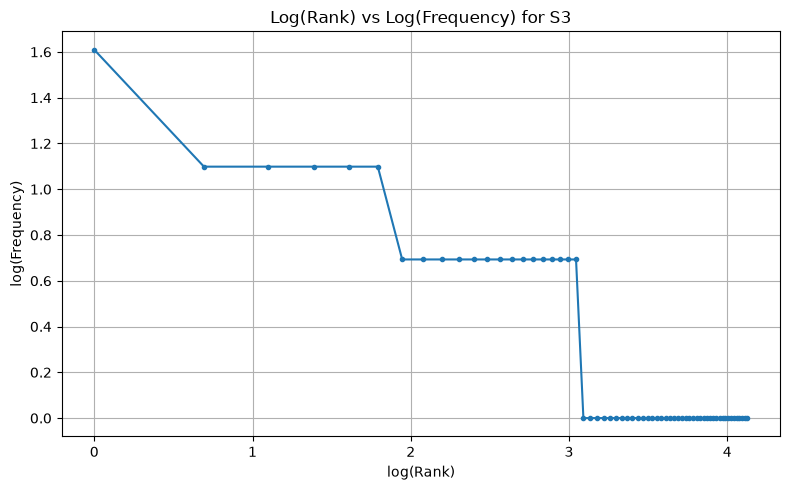


Top 5 bigrams in S1 (All tokens):


,Bigram,Frequency
0,. i,9
1,. the,4
2,yesterday .,3
3,i do,3
4,do n't,3



Top 5 bigrams in S3 (Final tokens):


,Bigram,Frequency
0,n't know,3
1,know changed,3
2,resetting password,2
3,could n't,2
4,n't connect,2


In [14]:
# Your code

import string
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.util import bigrams
from nltk.stem import PorterStemmer

# Collect tokens from all existing tickets
S1 = []  # All tokens
S2 = []  # All tokens excluding punctuation
S3 = []  # Final tokens after preprocessing

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])

    # Normalize case for consistent corpus statistics
    all_tokens = [token.lower() for token in result["tokens"]]

    # Exclude punctuation tokens
    no_punctuation = [
        token for token in all_tokens
        if not all(
            character in string.punctuation
            for character in token
        )
    ]

    final_tokens = [
        token.lower() for token in result["final_tokens"]
    ]

    S1.extend(all_tokens)
    S2.extend(no_punctuation)
    S3.extend(final_tokens)


# S4: Apply Porter stemming to S3
porter = PorterStemmer()
S4 = [porter.stem(token) for token in S3]


# PART 1: Corpus statistics
def corpus_statistics(name, tokens):
    total_tokens = len(tokens)
    unique_tokens = len(set(tokens))
    ttr = unique_tokens / total_tokens if total_tokens else 0

    return {
        "Corpus": name,
        "Total Tokens": total_tokens,
        "Unique Tokens": unique_tokens,
        "TTR": round(ttr, 4)
    }


stats = pd.DataFrame([
    corpus_statistics("S1 - All tokens", S1),
    corpus_statistics("S2 - No punctuation", S2),
    corpus_statistics("S3 - Final tokens", S3),
    corpus_statistics("S4 - Porter stemmed S3", S4)
])

print("CORPUS STATISTICS")
display(stats)


# PART 2: Top 10 words in S1 and S3
def show_top_words(name, tokens, n=10):
    print(f"\nTop {n} words in {name}:")
    freq = Counter(tokens)

    display(pd.DataFrame(
        freq.most_common(n),
        columns=["Word", "Frequency"]
    ))


show_top_words("S1 (All tokens)", S1)
show_top_words("S3 (Final tokens)", S3)


# PART 3: Log(rank) vs log(frequency) for S3
frequency = Counter(S3)
ranked_frequencies = sorted(
    frequency.values(),
    reverse=True
)

ranks = list(range(1, len(ranked_frequencies) + 1))

log_ranks = [math.log(rank) for rank in ranks]
log_frequencies = [
    math.log(freq) for freq in ranked_frequencies
]

plt.figure(figsize=(8, 5))
plt.plot(log_ranks, log_frequencies, marker=".")
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.title("Log(Rank) vs Log(Frequency) for S3")
plt.grid(True)
plt.tight_layout()
plt.show()


# PART 4: Top 5 bigrams in S1 and S3
def show_top_bigrams(name, tokens, n=5):
    # Bigrams are pairs of consecutive tokens
    bigram_counts = Counter(bigrams(tokens))

    print(f"\nTop {n} bigrams in {name}:")

    bigram_table = pd.DataFrame(
        [
            (" ".join(pair), count)
            for pair, count in bigram_counts.most_common(n)
        ],
        columns=["Bigram", "Frequency"]
    )

    display(bigram_table)


show_top_bigrams("S1 (All tokens)", S1)
show_top_bigrams("S3 (Final tokens)", S3)


**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*